# 08 — Result Plots

Predicted vs. actual plots, cross-model error comparison, and feature importance analysis on the LHS holdout —
these are the comparison visuals the task explicitly asks for, using the final tuned models saved from
`05_Hyperparameter_Tuning.ipynb`.

In [16]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [17]:
# Input and Target Columns
input_columns = [
    "pressure_atm",
    "requested_vapor_fraction",
    "benzene_feed_fraction",
    "stages",
    "feed_stage_fraction",
    "reflux_ratio",
    "bottoms_fraction",
]

target_columns = [
    "x_D_benzene",
    "x_B_benzene",
    "Q_C",
    "Q_R",
]


# Load Trained Models
model_dir = "../models/01_trained_models_all_5"

rf_best = joblib.load(f"{model_dir}/random_forest.pkl")
xgb_best = joblib.load(f"{model_dir}/xgboost.pkl")
svr_best = joblib.load(f"{model_dir}/svr.pkl")
ann_best = joblib.load(f"{model_dir}/ann.pkl")
lin_final = joblib.load(f"{model_dir}/polynomial_regression.pkl")


# Load Preprocessing Objects
scaler_X = joblib.load(f"{model_dir}/scaler_X.pkl")
scaler_y = joblib.load(f"{model_dir}/scaler_y.pkl")
poly = joblib.load(f"{model_dir}/poly_features.pkl")


# Load Holdout Data
lhs_df = pd.read_csv(
    "../data/03_raw_holdout_lhs/lhs_500_converged.csv"
)

X_holdout = lhs_df[input_columns]
y_holdout = lhs_df[target_columns]


# Prediction Function
def get_predictions(model_name):

    # Random Forest
    if model_name == "RandomForest":
        return rf_best.predict(X_holdout)

    # XGBoost
    if model_name == "XGBoost":
        return xgb_best.predict(X_holdout)

    # SVR
    if model_name == "SVR":
        return svr_best.predict(
            scaler_X.transform(X_holdout)
        )

    # ANN
    if model_name == "ANN":
        pred_scaled = ann_best.predict(
            scaler_X.transform(X_holdout)
        )
        return scaler_y.inverse_transform(pred_scaled)

    # Polynomial Regression
    if model_name == "PolynomialRegression":
        return lin_final.predict(
            poly.transform(X_holdout)
        )


# Models
models = [
    "RandomForest",
    "XGBoost",
    "SVR",
    "ANN",
    "PolynomialRegression",
]


# Generate Predictions
predictions = {
    name: get_predictions(name)
    for name in models
}

## Predicted vs Actual — all models, all outputs

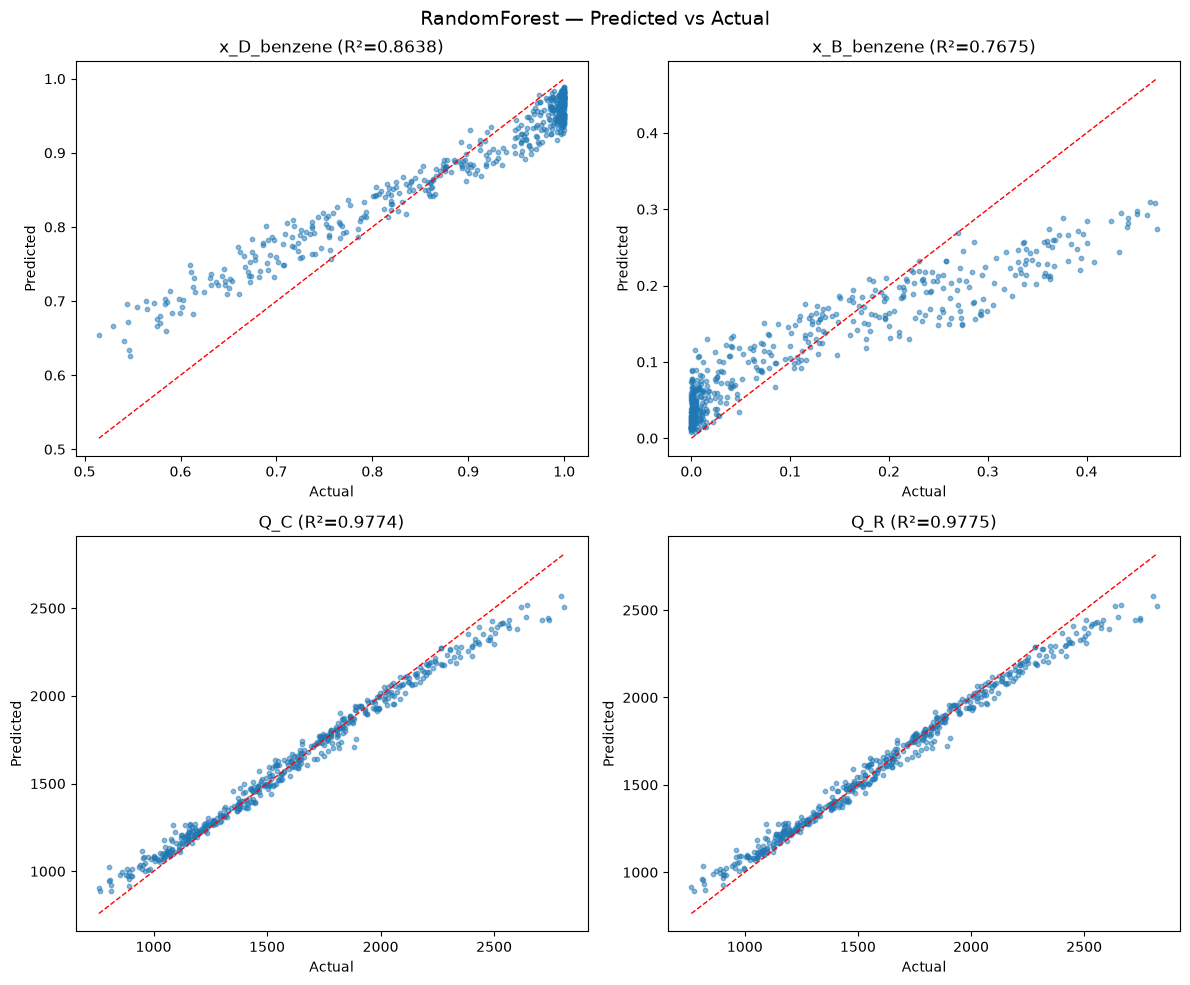

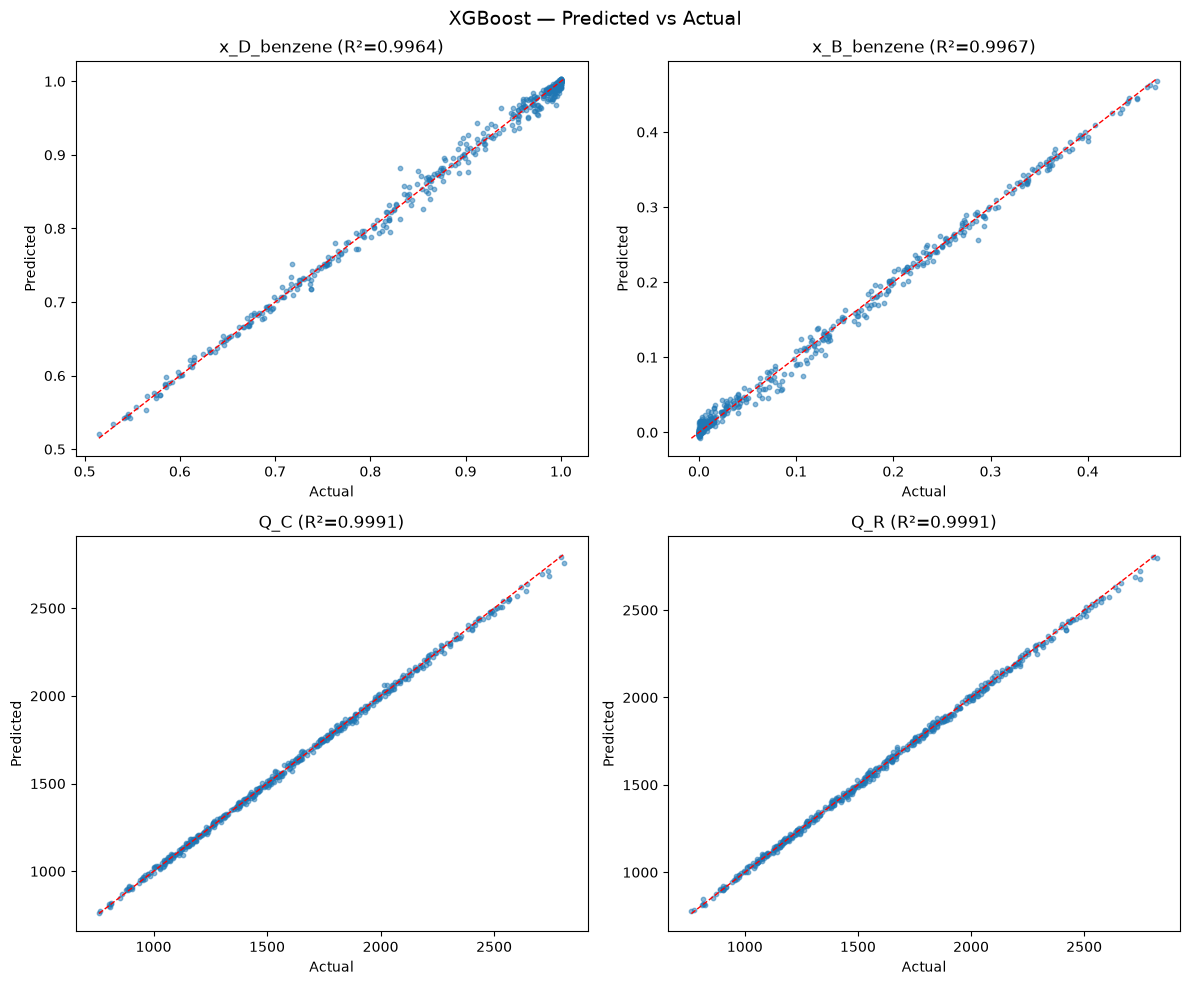

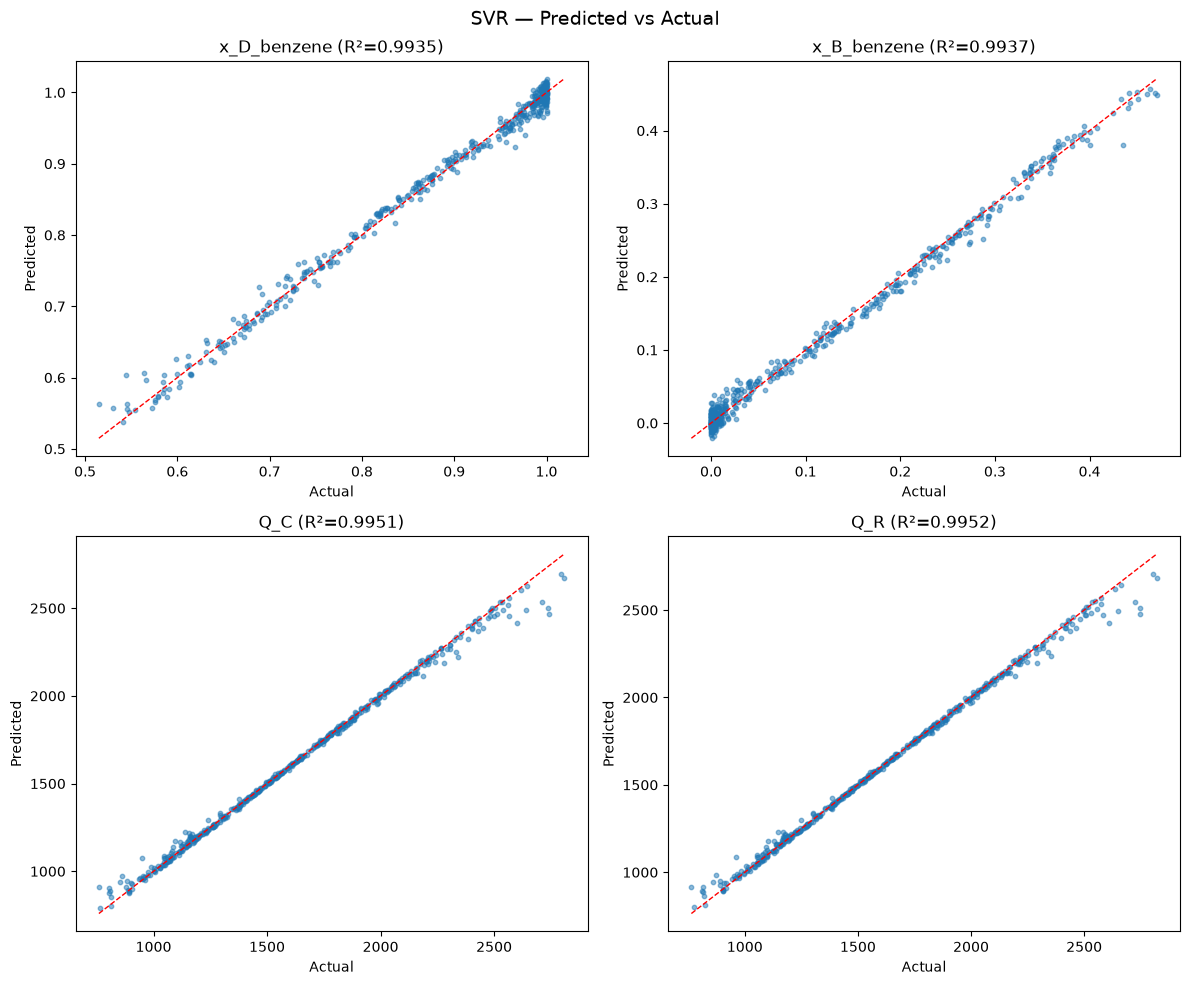

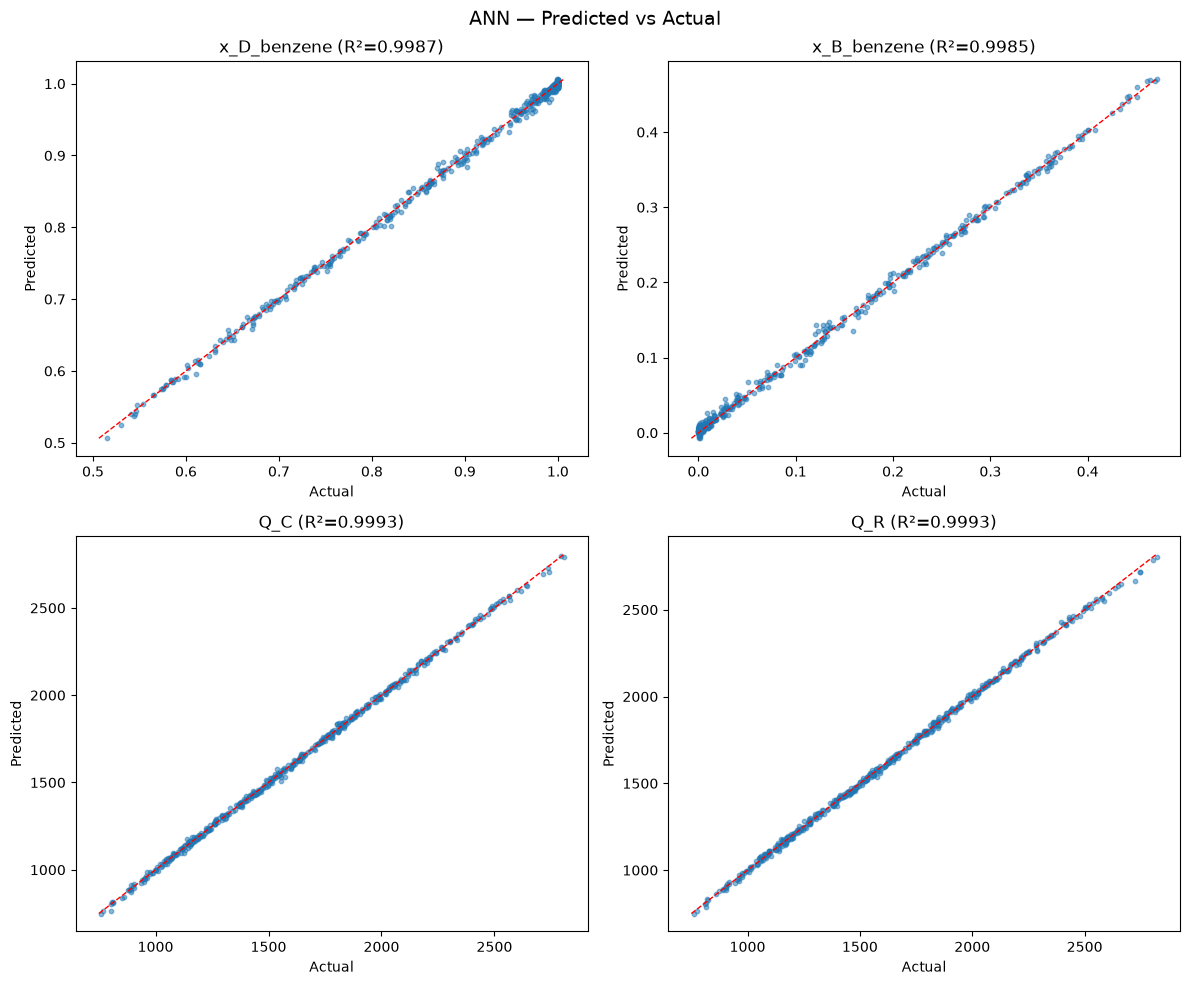

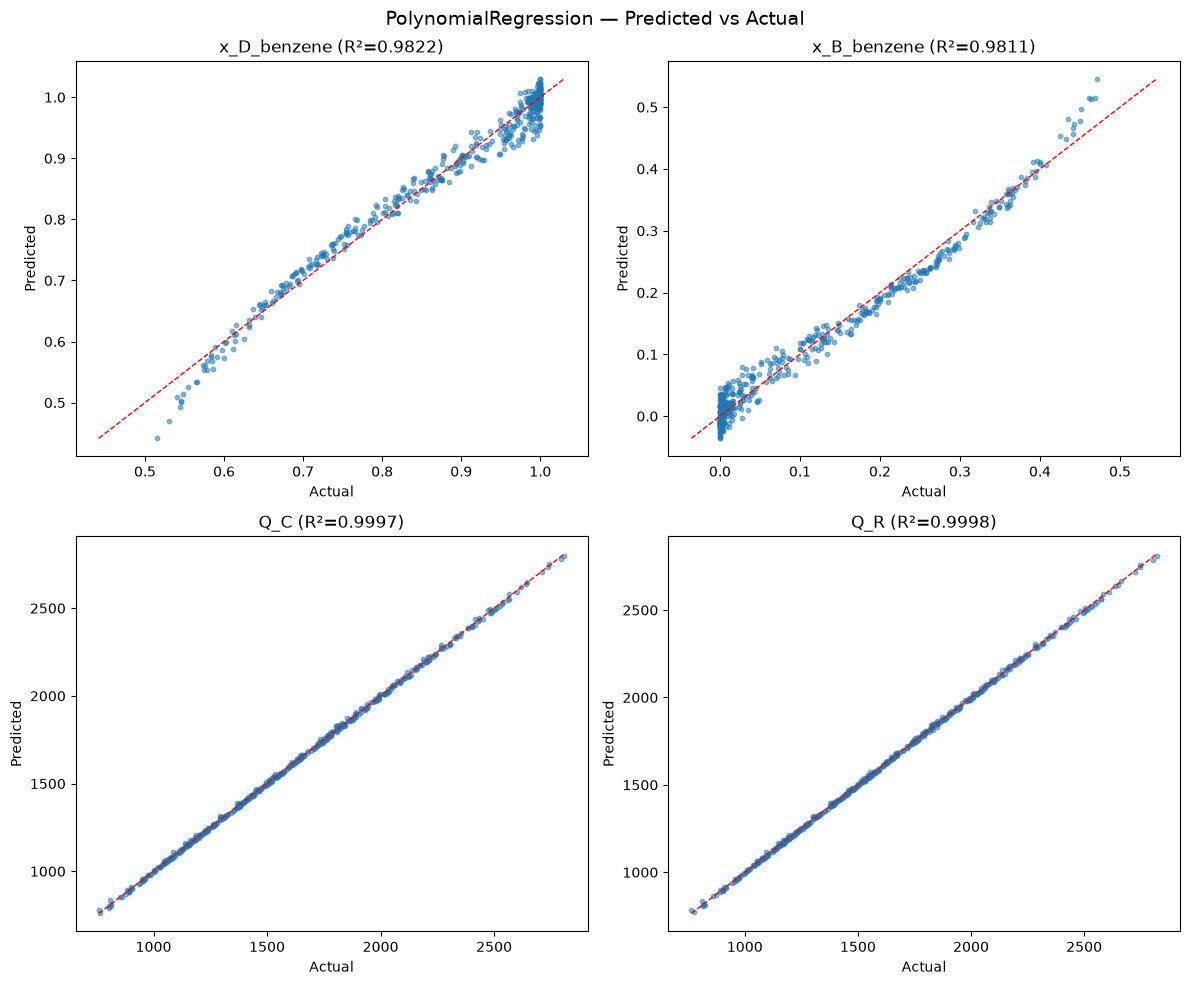

In [18]:
# Predicted vs Actual — One Figure Per Model

for name in models:

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(12, 10)
    )

    axes = axes.ravel()

    for i, target in enumerate(target_columns):

        ax = axes[i]

        y_true = y_holdout[target].values
        y_pred = predictions[name][:, i]

        ax.scatter(
            y_true,
            y_pred,
            s=10,
            alpha=0.5
        )

        lims = [
            min(y_true.min(), y_pred.min()),
            max(y_true.max(), y_pred.max())
        ]

        ax.plot(
            lims,
            lims,
            "r--",
            linewidth=1
        )

        r2 = r2_score(
            y_true,
            y_pred
        )

        ax.set_title(
            f"{target} (R²={r2:.4f})"
        )

        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted")

    fig.suptitle(
        f"{name} — Predicted vs Actual",
        fontsize=14
    )

    plt.tight_layout()

    filename = (
        f"../outputs/plots/"
        f"predicted_vs_actual_{name}.png"
    )

    plt.savefig(
        filename,
        dpi=150
    )

    plt.show()

## Error Comparison Across Models

In [19]:
# Error Metrics

error_rows = []

for name in models:

    for i, target in enumerate(target_columns):

        y_true = y_holdout[target].values
        y_pred = predictions[name][:, i]

        error_rows.append({
            "model": name,
            "target": target,
            "MAE": mean_absolute_error(
                y_true,
                y_pred
            ),
            "RMSE": np.sqrt(
                mean_squared_error(
                    y_true,
                    y_pred
                )
            ),
            "R2": r2_score(
                y_true,
                y_pred
            ),
        })


error_df = pd.DataFrame(error_rows)

error_df.to_csv(
    "../data/06_physical_checks/holdout_error_metrics.csv",
    index=False
)

print(error_df)

                   model       target        MAE       RMSE        R2
0           RandomForest  x_D_benzene   0.040879   0.050174  0.863754
1           RandomForest  x_B_benzene   0.049839   0.064141  0.767484
2           RandomForest          Q_C  49.596379  68.446868  0.977360
3           RandomForest          Q_R  49.539999  68.311766  0.977490
4                XGBoost  x_D_benzene   0.005387   0.008148  0.996407
5                XGBoost  x_B_benzene   0.005504   0.007647  0.996695
6                XGBoost          Q_C  10.441293  13.407196  0.999131
7                XGBoost          Q_R  10.820080  13.927270  0.999064
8                    SVR  x_D_benzene   0.008244   0.010969  0.993488
9                    SVR  x_B_benzene   0.008358   0.010572  0.993684
10                   SVR          Q_C  14.697447  31.775280  0.995121
11                   SVR          Q_R  14.357735  31.425417  0.995236
12                   ANN  x_D_benzene   0.003681   0.004828  0.998739
13                  

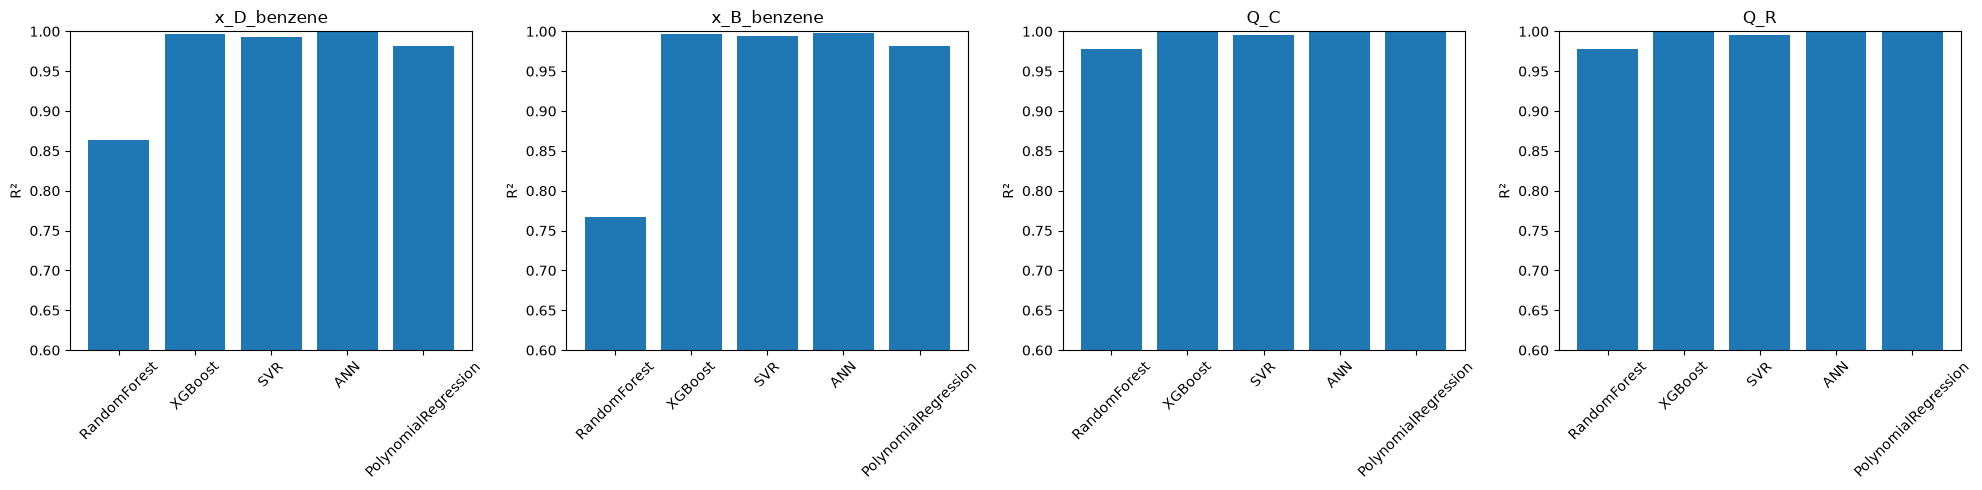

In [20]:
fig, axes = plt.subplots(1, len(target_columns), figsize=(20, 5))

for i, target in enumerate(target_columns):
    subset = error_df[error_df["target"] == target]
    axes[i].bar(subset["model"], subset["R2"])
    axes[i].set_title(target)
    axes[i].set_ylabel("R²")
    axes[i].set_ylim(0.6, 1.0)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("../outputs/plots/error_comparison_r2.png", dpi=150)
plt.show()

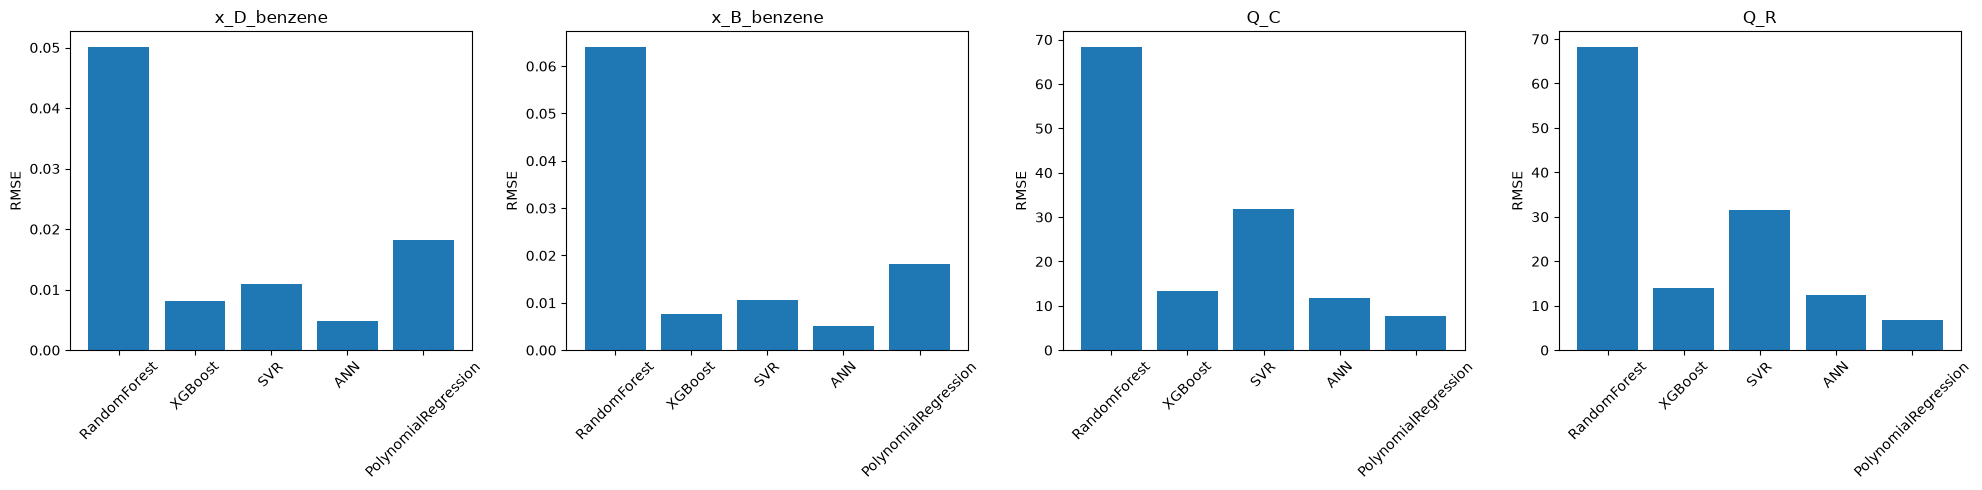

In [21]:
fig, axes = plt.subplots(1, len(target_columns), figsize=(20, 5))

for i, target in enumerate(target_columns):
    subset = error_df[error_df["target"] == target]
    axes[i].bar(subset["model"], subset["RMSE"])
    axes[i].set_title(target)
    axes[i].set_ylabel("RMSE")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("../outputs/plots/error_comparison_rmse.png", dpi=150)
plt.show()